# Notebook 02 — Classical ML Baselines

Logistic Regression and XGBoost for multi-horizon PD modeling on Lending Club data.

Key purpose: establish AUC benchmarks and demonstrate probability inconsistency across horizons—the core limitation that motivates survival modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

## Load Clean Dataset

In [2]:
df = pd.read_csv('../data/lendingclub_survival_clean.csv')
df.shape

(2247571, 13)

## Feature Set

In [3]:
features = ['annual_inc','dti','loan_amnt','int_rate']
X = df[features]

## Horizon Labels

In [4]:
horizons = [12,24,36]
for H in horizons:
    df[f'y_{H}'] = ((df['time'] <= H) & (df['event'] == 1)).astype(int)
df[[f'y_{H}' for H in horizons]].mean()

y_12    0.048525
y_24    0.098970
y_36    0.122606
dtype: float64

## Train/Test Split

In [5]:
X_train, X_test, idx_train, idx_test = train_test_split(
    X, df.index, test_size=0.3, random_state=42
)

## Logistic Regression

In [6]:
log_models = {}
for H in horizons:
    y_tr = df.loc[idx_train, f'y_{H}']
    y_te = df.loc[idx_test, f'y_{H}']
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=200))
    ])
    pipe.fit(X_train, y_tr)
    preds = pipe.predict_proba(X_test)[:,1]
    print(f'Logistic AUC @ {H}m:', roc_auc_score(y_te, preds))
    log_models[H] = pipe

Logistic AUC @ 12m: 0.6919755560529677
Logistic AUC @ 24m: 0.6799925368626997
Logistic AUC @ 36m: 0.6753458865862458


## XGBoost

In [7]:
xgb_models = {}
for H in horizons:
    y_tr = df.loc[idx_train, f'y_{H}']
    y_te = df.loc[idx_test, f'y_{H}']
    model = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42
    )
    model.fit(X_train, y_tr)
    preds = model.predict_proba(X_test)[:,1]
    print(f'XGBoost AUC @ {H}m:', roc_auc_score(y_te, preds))
    xgb_models[H] = model

XGBoost AUC @ 12m: 0.7068458003607616
XGBoost AUC @ 24m: 0.7036746503960176
XGBoost AUC @ 36m: 0.7051805101285109


## Probability Inconsistency Across Horizons

Independent models trained at 12m, 24m, and 36m have no guarantee that:

    P(default by 12m) ≤ P(default by 24m) ≤ P(default by 36m)

The plots below show that for the same borrower, the 12m PD can exceed the 36m PD—a logical impossibility.
This motivates the survival modeling approach in Notebooks 03 and 04.

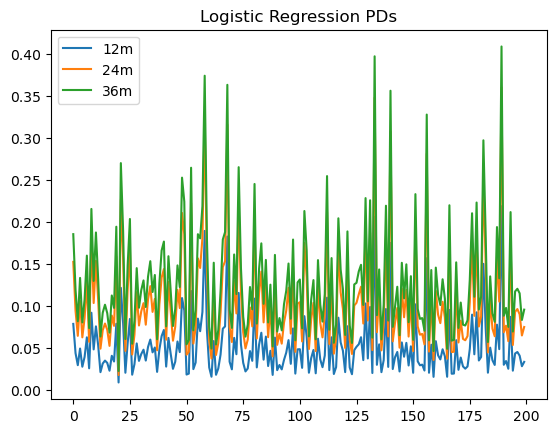

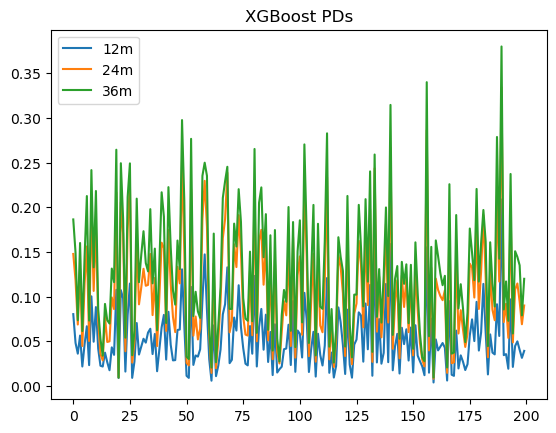

In [8]:
sample = idx_test[:200]
pd_lr = {H: log_models[H].predict_proba(X.loc[sample])[:,1] for H in horizons}
pd_xgb = {H: xgb_models[H].predict_proba(X.loc[sample])[:,1] for H in horizons}

plt.plot(pd_lr[12], label='12m')
plt.plot(pd_lr[24], label='24m')
plt.plot(pd_lr[36], label='36m')
plt.title('Logistic Regression PDs')
plt.legend(); plt.show()

plt.plot(pd_xgb[12], label='12m')
plt.plot(pd_xgb[24], label='24m')
plt.plot(pd_xgb[36], label='36m')
plt.title('XGBoost PDs')
plt.legend(); plt.show()

## Summary

| Model | AUC @ 12m | AUC @ 24m | AUC @ 36m |
|-------|-----------|-----------|----------|
| Logistic Regression | 0.692 | 0.680 | 0.675 |
| XGBoost | **0.707** | **0.704** | **0.705** |

**Takeaways:**
- XGBoost outperforms Logistic Regression by ~1.5 AUC points across all horizons
- AUC is stable across horizons, suggesting these features capture general creditworthiness rather than time-specific risk
- Despite acceptable AUC, both models violate PD monotonicity (see chart above)—the fundamental limitation that survival models resolve